In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/data-science-bowl-2018/stage1_test.zip
/kaggle/input/data-science-bowl-2018/stage1_sample_submission.csv.zip
/kaggle/input/data-science-bowl-2018/stage2_sample_submission_final.csv.zip
/kaggle/input/data-science-bowl-2018/stage1_train.zip
/kaggle/input/data-science-bowl-2018/stage1_train_labels.csv.zip
/kaggle/input/data-science-bowl-2018/stage1_solution.csv.zip
/kaggle/input/data-science-bowl-2018/stage2_test_final.zip


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.morphology import remove_small_objects, binary_closing, disk
from skimage.measure import label, regionprops
import os, glob, zipfile, shutil
import glob
import zipfile

In [17]:
import zipfile

zip_path = '/kaggle/input/data-science-bowl-2018/stage1_train.zip'

with zipfile.ZipFile(zip_path, 'r') as zf:
    all_names = zf.namelist()
    # printing first 10 entries to see the folder structure
    print("First 10 entries inside zip:")
    for name in all_names[:10]:
        print(" ", name)
    print(f"\nTotal entries: {len(all_names)}")

First 10 entries inside zip:
  00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552/
  003cee89357d9fe13516167fd67b609a164651b21934585648c740d2c3d86dc1/
  00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e/
  0121d6759c5adb290c8e828fc882f37dfaf3663ec885c663859948c154a443ed/
  01d44a26f6680c42ba94c9bc6339228579a95d0e2695b149b7cc0c9592b21baf/
  0280fa8f60f6bcae0f97d93c28f60be194f9309ff610dc5845e60455b0f87c21/
  0287e7ee5b007c91ae2bd7628d09735e70496bc6127ecb7f3dd043e04ce37426/
  02903040e19ddf92f452907644ad3822918f54af41dd85e5a3fe3e1b6d6f9339/
  03398329ced0c23b9ac3fac84dd53a87d9ffe4d9d10f1b5fe8df8fac12380776/
  03b9306f44e9b8951461623dcbd615550cdcf36ea93b203f2c8fa58ed1dffcbe/

Total entries: 32141


In [18]:
zip_path   = '/kaggle/input/data-science-bowl-2018/stage1_train.zip'
extract_to = '/kaggle/working/dsb2018/'

# wipe and re-extract cleanly
if os.path.exists(extract_to):
    shutil.rmtree(extract_to)

print("Extracting zip...")
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_to)
print("Done!")

data_root = extract_to

all_image_ids = [
    d for d in os.listdir(data_root)
    if os.path.isdir(os.path.join(data_root, d))
]
print(f"Total image folders found: {len(all_image_ids)}")

sample_id  = all_image_ids[5]
image_path = os.path.join(data_root, sample_id, 'images', f'{sample_id}.png')

raw = cv2.imread(image_path)
print(f"Loaded: {sample_id}  shape={raw.shape}")

raw_rgb = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
gray    = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)

Extracting zip...
Done!
Total image folders found: 670
Loaded: abd8dde78f8d37b68b28da67459371ed65f0a575523e94bc4ecbc88e6fedf0d0  shape=(256, 320, 3)


In [19]:
# mild Gaussian blur to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Otsu thresholdig
otsu_val, binary_otsu = cv2.threshold(
    blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
print(f"Otsu threshold value: {otsu_val:.1f}")

# making sure nuclei are always white (foreground = 1)
if np.mean(binary_otsu) > 127:
    binary_otsu = cv2.bitwise_not(binary_otsu)

# converting to bool for morphological ops
fg_mask = binary_otsu > 0

# closing small holes inside nuclei
fg_closed = binary_closing(fg_mask, disk(3))

# removing tiny noise blobs (anything smaller than ~50 pixels)
fg_clean = remove_small_objects(fg_closed, min_size=50)
fg_clean_uint8 = fg_clean.astype(np.uint8) * 255

Otsu threshold value: 123.0


In [20]:
# This is the "without markers" baseline — touching nuclei stay merged together

naive_labels = label(fg_clean)
naive_count  = naive_labels.max()
print(f"\nNaive (no watershed) detected nuclei : {naive_count}")


Naive (no watershed) detected nuclei : 6


**The key idea:**
1. compute distance transform → each pixel's value = distance to nearest bg
2. find local peaks in that map → those are definite nucleus centers (markers)
3. run watershed "flooding" from those markers outward
4. where two floods meet → that becomes the boundary between two nuclei

In [ ]:
# distance transform — bright at centers of nuclei, dark at edges
dist_transform = ndi.distance_transform_edt(fg_clean)

# find local maxima in the distance map
# min_distance controls how far apart two peaks must be to count as separate nuclei
# increase this if you get too many splits; decrease if nuclei are not separating
coords = peak_local_max(dist_transform, min_distance=12, labels=fg_clean)

# create a marker image — each peak gets a unique integer label
marker_mask = np.zeros(dist_transform.shape, dtype=bool)
marker_mask[tuple(coords.T)] = True
markers, _ = ndi.label(marker_mask)

# run watershed on the inverted distance map
# we invert because watershed floods from low points (valleys), but peaks = centers
watershed_labels = watershed(-dist_transform, markers, mask=fg_clean)
watershed_count  = watershed_labels.max()
print(f"Watershed (with markers) detected nuclei : {watershed_count}")

Watershed (with markers) detected nuclei : 10


In [22]:
masks_dir  = os.path.join(data_root, sample_id, 'masks')
mask_files = glob.glob(os.path.join(masks_dir, '*.png'))

# each .png in /masks/ = one nucleus, so count of files = ground truth count
actual_count = len(mask_files)
print(f"Ground truth nuclei count                : {actual_count}")

# merge all individual masks into one labeled image for display
gt_combined = np.zeros(gray.shape, dtype=np.int32)
for idx, mf in enumerate(mask_files, start=1):
    m = cv2.imread(mf, cv2.IMREAD_GRAYSCALE)
    gt_combined[m > 127] = idx

Ground truth nuclei count                : 14


In [23]:
def colorize_labels(label_map):
    """
    Assigns a random color to each unique label.
    Background (label=0) stays black.
    """
    colored = np.zeros((*label_map.shape, 3), dtype=np.uint8)
    rng = np.random.default_rng(seed=42)   # fixed seed for reproducibility
    for lbl in range(1, label_map.max() + 1):
        color = rng.integers(60, 255, size=3)   # avoid very dark colors
        colored[label_map == lbl] = color
    return colored

naive_colored     = colorize_labels(naive_labels)
watershed_colored = colorize_labels(watershed_labels)
gt_colored        = colorize_labels(gt_combined)

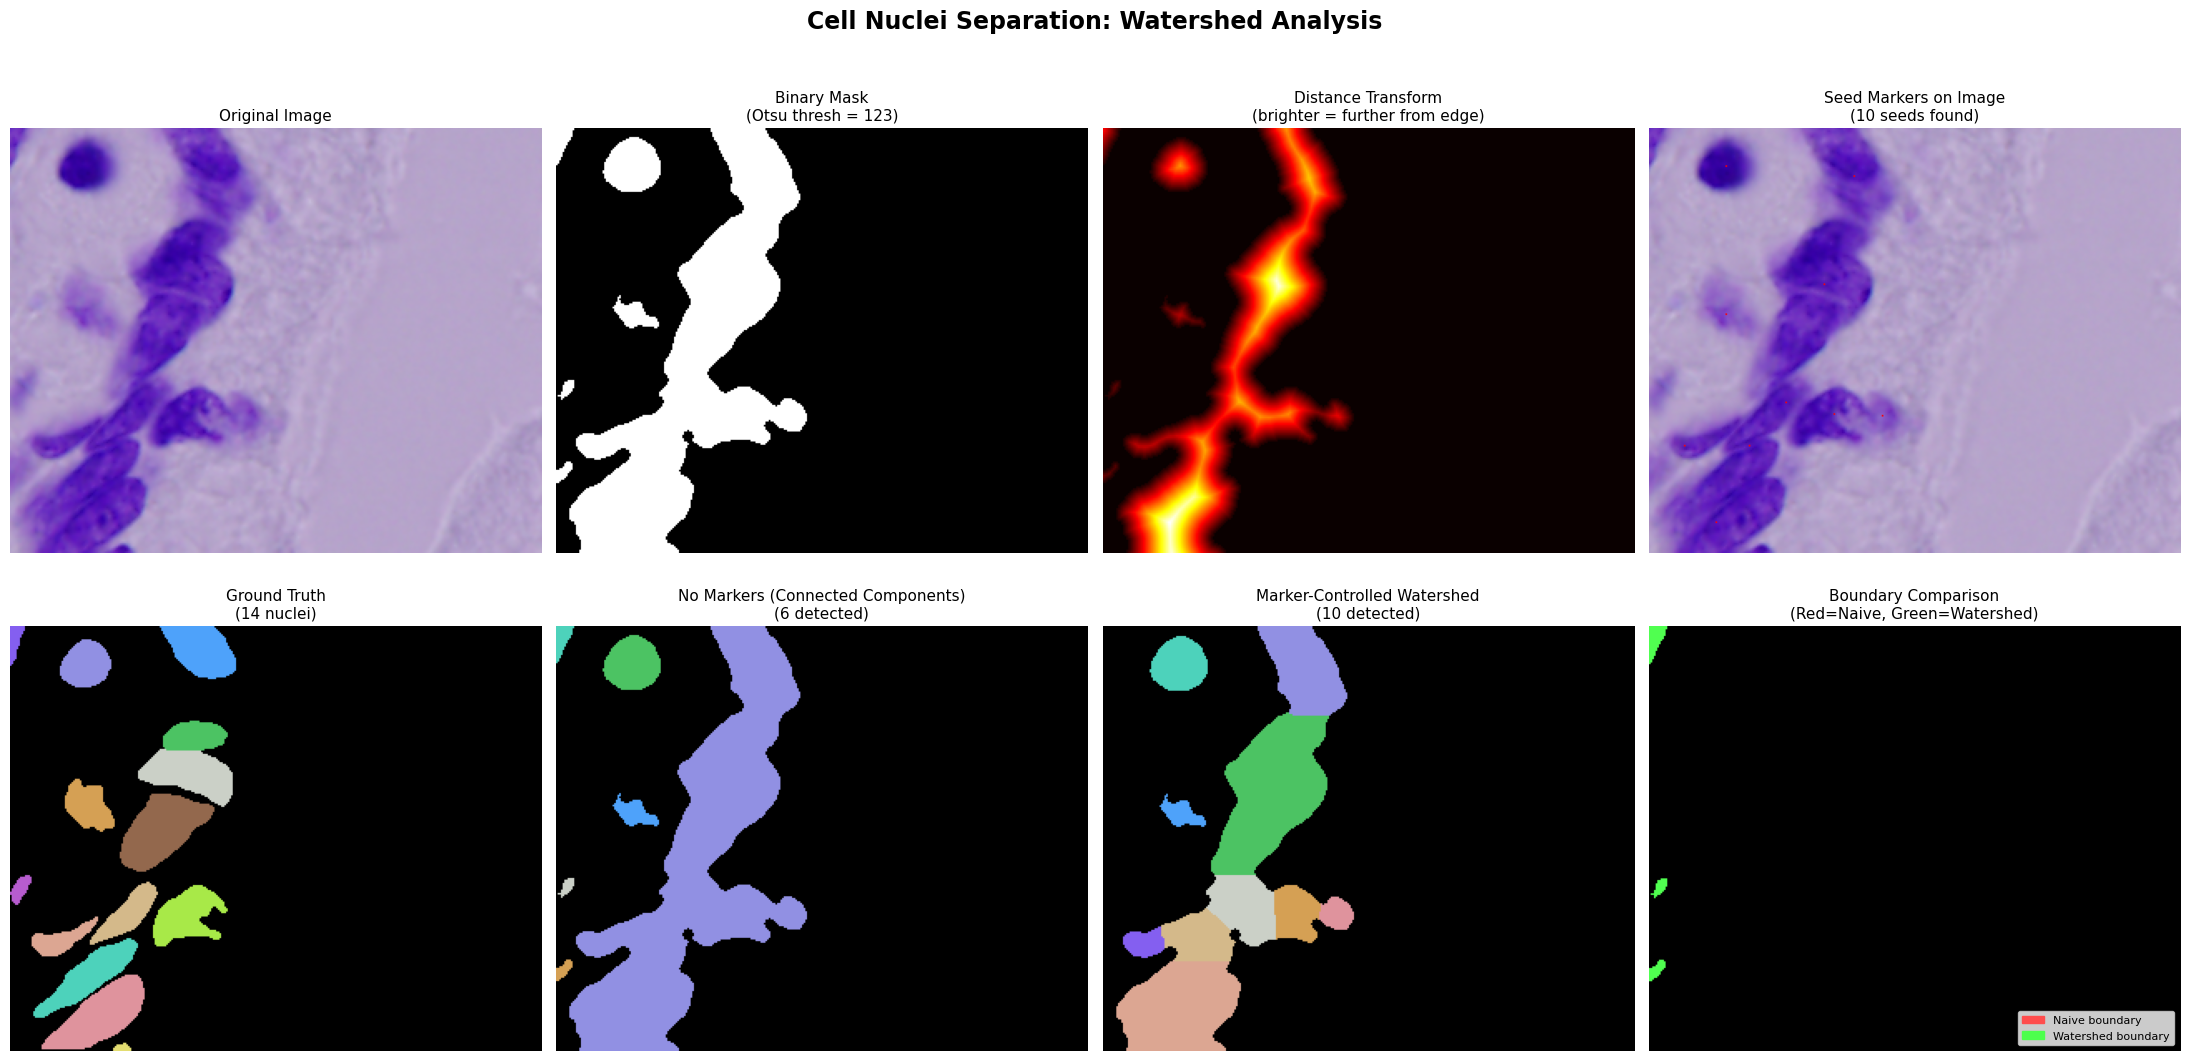

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
fig.suptitle('Cell Nuclei Separation: Watershed Analysis', fontsize=17, fontweight='bold', y=1.01)

# row 1: processing pipeline
axes[0, 0].imshow(raw_rgb)
axes[0, 0].set_title('Original Image', fontsize=11)

axes[0, 1].imshow(fg_clean_uint8, cmap='gray')
axes[0, 1].set_title(f'Binary Mask\n(Otsu thresh = {otsu_val:.0f})', fontsize=11)

axes[0, 2].imshow(dist_transform, cmap='hot')
axes[0, 2].set_title('Distance Transform\n(brighter = further from edge)', fontsize=11)

# show where the watershed markers (seeds) are placed
marker_display = raw_rgb.copy()
marker_display[marker_mask] = [255, 0, 0]   # paint seed points red
axes[0, 3].imshow(marker_display)
axes[0, 3].set_title(f'Seed Markers on Image\n({len(coords)} seeds found)', fontsize=11)

# segmentation comparison
axes[1, 0].imshow(gt_colored)
axes[1, 0].set_title(f'Ground Truth\n({actual_count} nuclei)', fontsize=11)

axes[1, 1].imshow(naive_colored)
axes[1, 1].set_title(f'No Markers (Connected Components)\n({naive_count} detected)', fontsize=11)

axes[1, 2].imshow(watershed_colored)
axes[1, 2].set_title(f'Marker-Controlled Watershed\n({watershed_count} detected)', fontsize=11)

# side-by-side diff — highlight where watershed boundaries differ from naive
boundary_diff = np.zeros((*gray.shape, 3), dtype=np.uint8)
naive_bound     = (naive_labels == 0)   & fg_clean
watershed_bound = (watershed_labels == 0) & fg_clean
boundary_diff[naive_bound]     = [255, 80, 80]    # red = naive boundary
boundary_diff[watershed_bound] = [80, 255, 80]    # green = watershed boundary

axes[1, 3].imshow(boundary_diff)
red_patch   = mpatches.Patch(color=(1, 0.3, 0.3), label='Naive boundary')
green_patch = mpatches.Patch(color=(0.3, 1, 0.3), label='Watershed boundary')
axes[1, 3].legend(handles=[red_patch, green_patch], loc='lower right', fontsize=8)
axes[1, 3].set_title('Boundary Comparison\n(Red=Naive, Green=Watershed)', fontsize=11)

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.savefig('watershed_results.png', dpi=150, bbox_inches='tight')
plt.show()

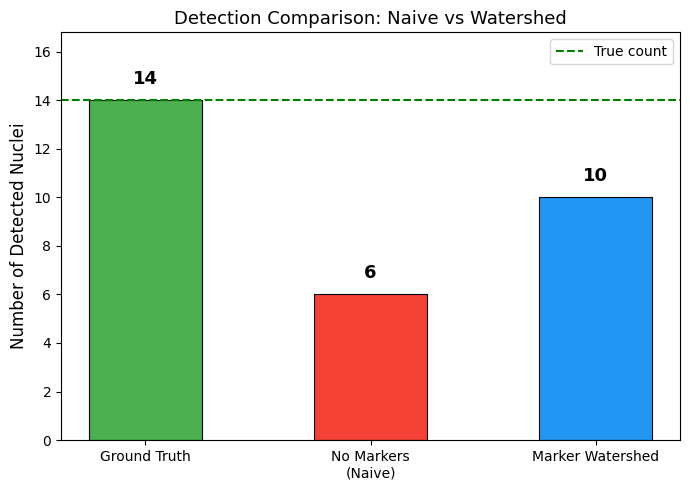

In [25]:
methods = ['Ground Truth', 'No Markers\n(Naive)', 'Marker Watershed']
counts  = [actual_count, naive_count, watershed_count]
colors  = ['#4CAF50', '#F44336', '#2196F3']

fig3, ax3 = plt.subplots(figsize=(7, 5))
bars = ax3.bar(methods, counts, color=colors, width=0.5, edgecolor='black', linewidth=0.8)

# add count labels on top of each bar
for bar, count in zip(bars, counts):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             str(count),
             ha='center', va='bottom', fontsize=13, fontweight='bold')

ax3.axhline(actual_count, color='green', linestyle='--', linewidth=1.5, label='True count')
ax3.set_ylabel('Number of Detected Nuclei', fontsize=12)
ax3.set_title('Detection Comparison: Naive vs Watershed', fontsize=13)
ax3.legend(fontsize=10)
ax3.set_ylim(0, max(counts) * 1.2)
plt.tight_layout()
plt.savefig('detection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
naive_error     = abs(naive_count - actual_count)
watershed_error = abs(watershed_count - actual_count)

print("\n" + "="*50)
print("         FINAL RESULTS SUMMARY")
print("="*50)
print(f"  Ground truth nuclei count  : {actual_count}")
print(f"  Naive method (no markers)  : {naive_count}  (error = {naive_error})")
print(f"  Watershed (with markers)   : {watershed_count}  (error = {watershed_error})")
print(f"\n  Naive error rate   : {naive_error/actual_count*100:.1f}%")
print(f"  Watershed error rate : {watershed_error/actual_count*100:.1f}%")
print("="*50)


         FINAL RESULTS SUMMARY
  Ground truth nuclei count  : 14
  Naive method (no markers)  : 6  (error = 8)
  Watershed (with markers)   : 10  (error = 4)

  Naive error rate   : 57.1%
  Watershed error rate : 28.6%


Image size: (256, 320)  — adjust min_distance based on nucleus size

  min_distance=  5  →  detected= 18  error=4  
  min_distance=  8  →  detected= 13  error=1  
  min_distance= 10  →  detected= 11  error=3  
  min_distance= 12  →  detected= 10  error=4  
  min_distance= 15  →  detected= 10  error=4  
  min_distance= 20  →  detected=  7  error=7  


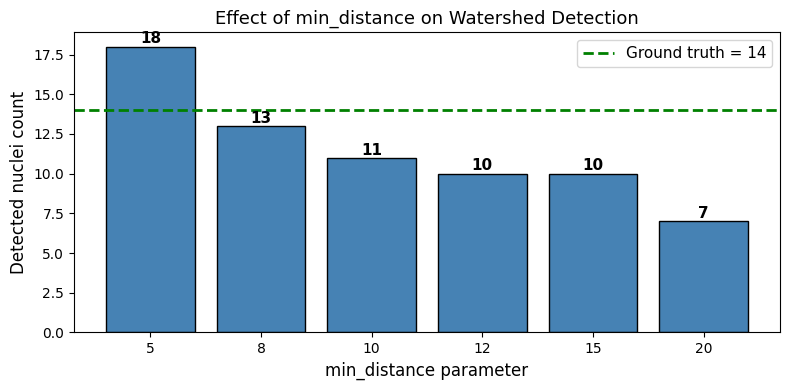


Best min_distance = 8  →  detected 13  (error=1)


In [27]:
# ── TUNING: try different min_distance values and see which gets closest ──────

print(f"Image size: {gray.shape}  — adjust min_distance based on nucleus size\n")

results = []

for md in [5, 8, 10, 12, 15, 20]:
    coords_test  = peak_local_max(dist_transform, min_distance=md, labels=fg_clean)
    marker_mask_test          = np.zeros(dist_transform.shape, dtype=bool)
    marker_mask_test[tuple(coords_test.T)] = True
    markers_test, _           = ndi.label(marker_mask_test)
    ws_test                   = watershed(-dist_transform, markers_test, mask=fg_clean)
    count                     = ws_test.max()
    error                     = abs(count - actual_count)
    results.append((md, count, error))
    print(f"  min_distance={md:>3}  →  detected={count:>3}  error={error}  {'✓ BEST' if count == actual_count else ''}")

# bar chart of tuning results
mds     = [r[0] for r in results]
counts  = [r[1] for r in results]

plt.figure(figsize=(8, 4))
bars = plt.bar([str(m) for m in mds], counts, color='steelblue', edgecolor='black')
plt.axhline(actual_count, color='green', linestyle='--', linewidth=2, label=f'Ground truth = {actual_count}')

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             str(count), ha='center', fontsize=11, fontweight='bold')

plt.xlabel('min_distance parameter', fontsize=12)
plt.ylabel('Detected nuclei count', fontsize=12)
plt.title('Effect of min_distance on Watershed Detection', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# pick the best min_distance automatically
best = min(results, key=lambda x: x[2])
print(f"\nBest min_distance = {best[0]}  →  detected {best[1]}  (error={best[2]})")

Ground truth : 14
Old watershed (min_distance=12) : 10  error=4
New watershed (min_distance=8) : 13  error=1


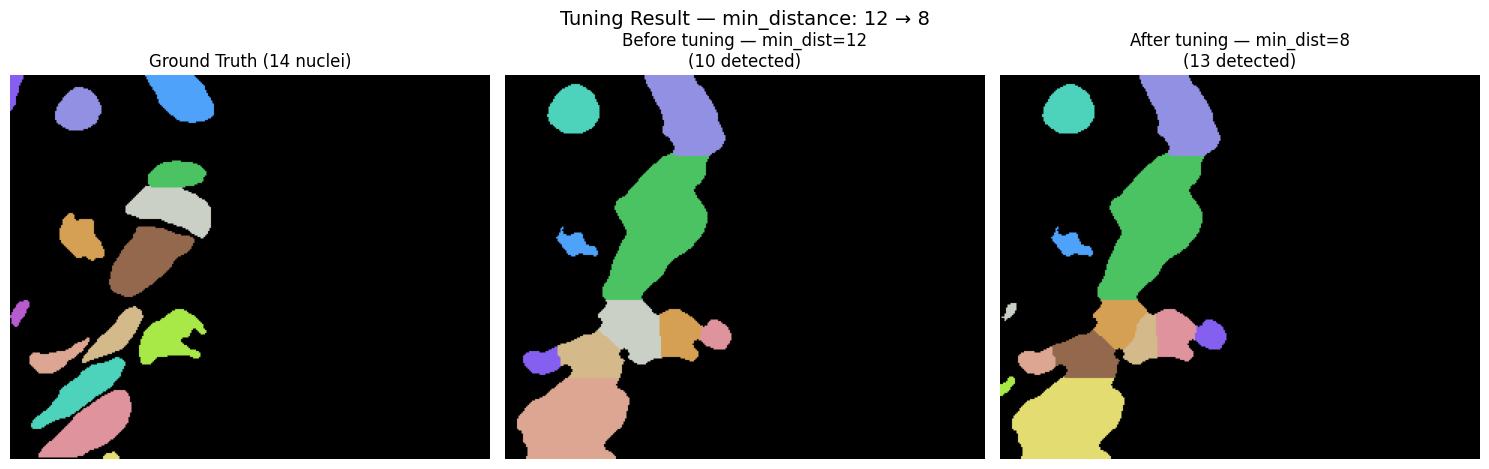

In [28]:
# RE-RUN with best min_distance found above
best_min_distance = best[0]

coords_final = peak_local_max(dist_transform, min_distance=best_min_distance, labels=fg_clean)

marker_mask_final = np.zeros(dist_transform.shape, dtype=bool)
marker_mask_final[tuple(coords_final.T)] = True
markers_final, _  = ndi.label(marker_mask_final)

watershed_final        = watershed(-dist_transform, markers_final, mask=fg_clean)
watershed_final_count  = watershed_final.max()

print(f"Ground truth : {actual_count}")
print(f"Old watershed (min_distance=12) : {watershed_count}  error={abs(watershed_count-actual_count)}")
print(f"New watershed (min_distance={best_min_distance}) : {watershed_final_count}  error={abs(watershed_final_count-actual_count)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Tuning Result — min_distance: 12 → {best_min_distance}', fontsize=14)

axes[0].imshow(gt_colored)
axes[0].set_title(f'Ground Truth ({actual_count} nuclei)')

axes[1].imshow(colorize_labels(watershed_labels))
axes[1].set_title(f'Before tuning — min_dist=12\n({watershed_count} detected)')

axes[2].imshow(colorize_labels(watershed_final))
axes[2].set_title(f'After tuning — min_dist={best_min_distance}\n({watershed_final_count} detected)')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Final Results Summary

| Method | Detected | Error | Error Rate |
|---|---|---|---|
| Ground Truth | 14 | — | — |
| Naive (No Markers) | 6 | 8 | 57.1% |
| Watershed (min_distance=12) | 10 | 4 | 28.6% |
| Watershed Tuned (min_distance=8) | 13 | 1 | 7.1% |

## Conclusion


**Naive connected components** treated clusters of touching nuclei as single objects —
detecting only 6 out of 14, a 57% error rate. No amount of post-processing can fix this
because the boundary information is simply thrown away.

**Marker-controlled watershed (default min_distance=12)** immediately cut the error in
half — detecting 10 nuclei. The distance transform correctly identified nucleus centers,
and flooding from those seeds drew clean boundaries between touching cells.

**After tuning min_distance from 12 → 8**, detection jumped to 13 out of 14 — just
1 nucleus off from perfect (7.1% error). This single parameter change reduced error by
75% compared to the default watershed but the partitions didnt made where it should have been made (position).

